# Housing Prediction


In [1]:
# import libraries
import pandas as pd
!pip install scikit-learn==1.8.0
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load the Data

In [3]:
housing_data = pd.read_csv("/data/housing.csv")
housing_data.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Explore the Data

In [4]:
housing_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
housing_data.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


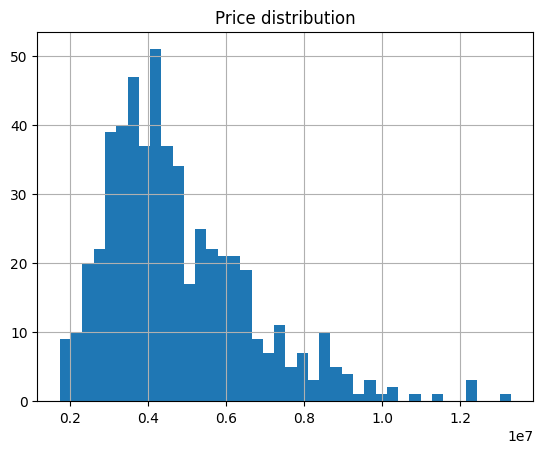

In [6]:
housing_data["price"].hist(bins=40)
plt.title("Price distribution")
plt.show()


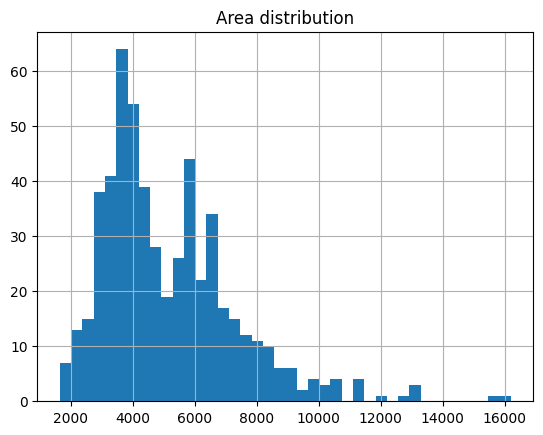

In [7]:
housing_data["area"].hist(bins=40)
plt.title("Area distribution")
plt.show()


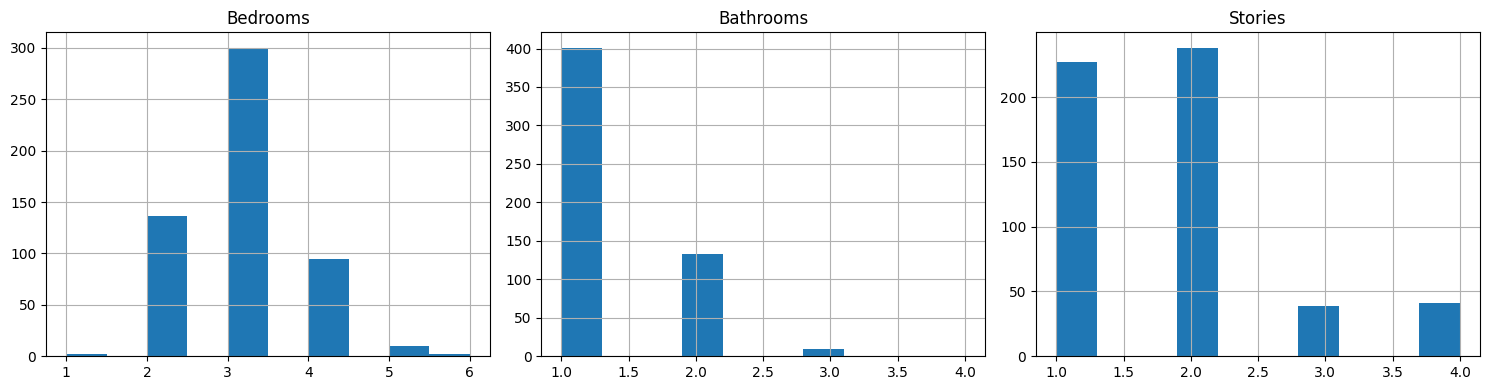

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
housing_data["bedrooms"].hist(ax=axes[0])
axes[0].set_title("Bedrooms")
housing_data["bathrooms"].hist(ax=axes[1])
axes[1].set_title("Bathrooms")
housing_data["stories"].hist(ax=axes[2])
axes[2].set_title("Stories")
plt.tight_layout()
plt.show()


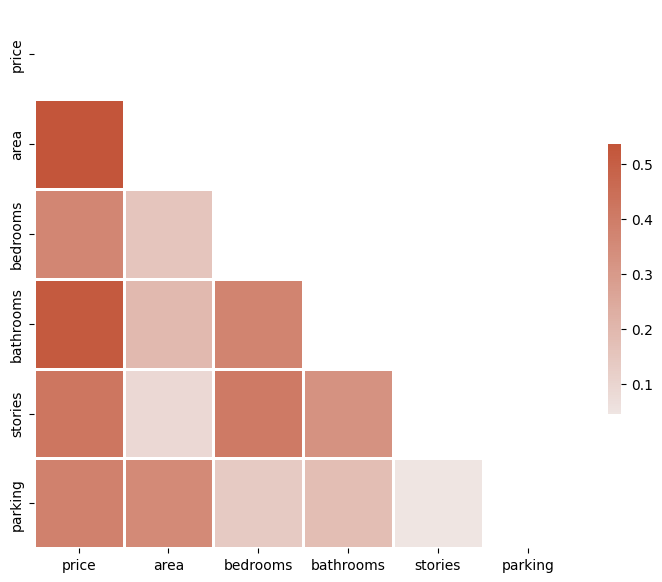

In [9]:
corr = housing_data.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
cmap = sns.diverging_palette(230, 20, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0, square=True, linewidths=1, cbar_kws={"shrink": .5})
plt.show()


## Stratified Train/Test Split


In [10]:
housing_data["price_cat"] = pd.cut(
    housing_data["price"],
    bins=[0, 3_430_000, 4_340_000, 5_740_000, np.inf],
    labels=[1, 2, 3, 4]
)
housing_data["price_cat"].value_counts()


,count
price_cat,
2,138
1,137
4,136
3,134


In [11]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing_data, housing_data["price_cat"]):
    strat_train_set = housing_data.loc[train_index]
    strat_test_set = housing_data.loc[test_index]

# price_cat was only scaffolding for the split - drop it now
strat_train_set = strat_train_set.drop("price_cat", axis="columns")
strat_test_set = strat_test_set.drop("price_cat", axis="columns")


In [12]:
housing = strat_train_set.drop("price", axis=1)
housing_labels = strat_train_set["price"].copy()

X_test_raw = strat_test_set.drop("price", axis=1)
y_test = strat_test_set["price"].copy()


## Feature Engineering

In [13]:
def feature_engineering(data):
    data = data.copy()
    data["area_per_story"] = data["area"] / data["stories"]
    data["bedrooms_per_story"] = data["bedrooms"] / data["stories"]
    data["bedrooms_per_area"] = data["bedrooms"] / data["area"]
    data["bathrooms_per_story"] = data["bathrooms"] / data["stories"]
    return data


### Build One Resuable Pipeline

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer

feature_engineering_transformer = FunctionTransformer(feature_engineering)

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("cat_encoder", OneHotEncoder(sparse_output=False, handle_unknown="ignore"))
])


In [15]:
num_attribs = ["stories", "parking", "area_per_story", "bedrooms_per_area",
               "bedrooms_per_story", "bathrooms_per_story"]
cat_attribs = ["mainroad", "guestroom", "basement", "hotwaterheating",
               "airconditioning", "prefarea", "furnishingstatus"]

preprocessing = ColumnTransformer([
    ("num", numeric_pipeline, num_attribs),
    ("cat", categorical_pipeline, cat_attribs),
])

full_preprocessing = Pipeline([
    ("feature_engineering", feature_engineering_transformer),
    ("preprocessing", preprocessing)
])


In [16]:
# Sanity check: fit on training data only, look at the shape
housing_prepared = full_preprocessing.fit_transform(housing)
housing_prepared.shape


(436, 21)

## Select and Train Models



### Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression

lin_pipeline = Pipeline([
    ("preprocessing", full_preprocessing),
    ("linear_reg", LinearRegression())
])
lin_pipeline.fit(housing, housing_labels)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('linear_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...x791884a28e00>
,"inverse_func inverse_func: callable, default=NoneThe callable to us

In [18]:
from sklearn.metrics import mean_squared_error

lin_predictions = lin_pipeline.predict(housing)
lin_rmse = np.sqrt(mean_squared_error(housing_labels, lin_predictions))
lin_rmse


np.float64(1115459.3983034499)

### Decision Tree Regressor

In [19]:
from sklearn.tree import DecisionTreeRegressor

tree_pipeline = Pipeline([
    ("preprocessing", full_preprocessing),
    ("tree_reg", DecisionTreeRegressor(random_state=42))
])
tree_pipeline.fit(housing, housing_labels)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('tree_reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...x791884a28e00>
,"inverse_func inverse_func: callable, default=NoneThe callable to use 

### Cross-Validation (Decision Tree)


In [20]:
from sklearn.model_selection import cross_val_score

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

tree_scores = cross_val_score(tree_pipeline, housing, housing_labels,
                               scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-tree_scores)
display_scores(tree_rmse_scores)


Scores: [2062491.04130286 1584804.65888329 1656399.22483846 1680762.5518442
 1584419.44666005 2436929.16742474 1564216.82052966 1885256.50726835
 1827927.70263118 1359673.15517199]
Mean: 1764288.027655478
Standard deviation: 291029.15480804764


### Random Forest Regressor

In [21]:
from sklearn.ensemble import RandomForestRegressor

forest_pipeline = Pipeline([
    ("preprocessing", full_preprocessing),
    ("random_forest", RandomForestRegressor(n_estimators=200, random_state=42))
])
forest_pipeline.fit(housing, housing_labels)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function fea...x791884a28e00>
,"inverse_func inverse_func: callable, default=NoneThe callable to

In [22]:
forest_scores = cross_val_score(forest_pipeline, housing, housing_labels,
                                 scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)


Scores: [1221551.31270237 1039516.70583501 1330029.31780191 1030105.57030277
 1020010.65467678 1529381.48359644 1172969.99494846 1347876.31028353
 1509823.12319625 1177008.86028498]
Mean: 1237827.33336285
Standard deviation: 178237.85419396104


### GridSearch

In [23]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"random_forest__n_estimators": [50, 100, 200], "random_forest__max_features": [4, 6, 8, 10]},
    {"random_forest__bootstrap": [True], "random_forest__n_estimators": [100, 200],
     "random_forest__max_features": [2, 3, 4]},
]

grid_search = GridSearchCV(forest_pipeline, param_grid, cv=10,
                            scoring="neg_mean_squared_error", return_train_score=True)
grid_search.fit(housing, housing_labels)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'random_forest__max_features': [4, 6, ...], 'random_forest__n_estimators': [50, 100, ...]}, {'random_forest__bootstrap': [True], 'random_forest__max_features': [2, 3, ...], 'random_forest__n_estimators': [100, 200]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose ver

In [24]:
grid_search.best_params_


{'random_forest__max_features': 8, 'random_forest__n_estimators': 100}

In [25]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)


1259484.4543240464 {'random_forest__max_features': 4, 'random_forest__n_estimators': 50}
1248872.7456481298 {'random_forest__max_features': 4, 'random_forest__n_estimators': 100}
1251333.6996733914 {'random_forest__max_features': 4, 'random_forest__n_estimators': 200}
1272811.4180814307 {'random_forest__max_features': 6, 'random_forest__n_estimators': 50}
1249886.691451819 {'random_forest__max_features': 6, 'random_forest__n_estimators': 100}
1247124.4547875277 {'random_forest__max_features': 6, 'random_forest__n_estimators': 200}
1240420.5656019298 {'random_forest__max_features': 8, 'random_forest__n_estimators': 50}
1227981.3285345365 {'random_forest__max_features': 8, 'random_forest__n_estimators': 100}
1243493.4214841614 {'random_forest__max_features': 8, 'random_forest__n_estimators': 200}
1244413.918827788 {'random_forest__max_features': 10, 'random_forest__n_estimators': 50}
1238436.2435916008 {'random_forest__max_features': 10, 'random_forest__n_estimators': 100}
1248639.592367

### Randomized Search

In [26]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distribs = {
    "random_forest__n_estimators": randint(low=1, high=201),
    "random_forest__max_features": randint(low=1, high=len(num_attribs) + 1),
}

rnd_search = RandomizedSearchCV(forest_pipeline, param_distributions=param_distribs,
                                 n_iter=10, cv=5, scoring="neg_mean_squared_error",
                                 random_state=42)
rnd_search.fit(housing, housing_labels)
rnd_search.best_params_


{'random_forest__max_features': 6, 'random_forest__n_estimators': 130}

In [27]:
cvres = rnd_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)

1257331.9118711697 {'random_forest__max_features': 4, 'random_forest__n_estimators': 93}
1272498.3422228864 {'random_forest__max_features': 3, 'random_forest__n_estimators': 72}
1310595.4945676613 {'random_forest__max_features': 5, 'random_forest__n_estimators': 21}
1303805.0104944124 {'random_forest__max_features': 2, 'random_forest__n_estimators': 75}
1267605.3882295599 {'random_forest__max_features': 3, 'random_forest__n_estimators': 88}
1260369.5964360032 {'random_forest__max_features': 5, 'random_forest__n_estimators': 100}
1270547.5784060815 {'random_forest__max_features': 3, 'random_forest__n_estimators': 150}
1494402.9028940054 {'random_forest__max_features': 5, 'random_forest__n_estimators': 2}
1259166.1840515784 {'random_forest__max_features': 4, 'random_forest__n_estimators': 158}
1255297.6589521817 {'random_forest__max_features': 6, 'random_forest__n_estimators': 130}


In [28]:
final_model = grid_search.best_estimator_

final_predictions = final_model.predict(X_test_raw)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_rmse

np.float64(1316373.7110111725)

In [29]:
from scipy import stats

confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
stats.t.interval(confidence, len(squared_errors) - 1,
                 loc=squared_errors.mean(),
                 scale=stats.sem(squared_errors))


(np.float64(893172440421.363), np.float64(2572507053661.289))

## Feature Importance



In [30]:
preprocessing_step = final_model.named_steps["preprocessing"].named_steps["preprocessing"]
feature_names = preprocessing_step.get_feature_names_out()
forest_step = final_model.named_steps["random_forest"]

feature_importance_list = sorted(
    zip(feature_names, forest_step.feature_importances_),
    key=lambda x: x[1], reverse=True
)
feature_importance_list


[('num__bedrooms_per_area', np.float64(0.12026320009841583)),
 ('num__parking', np.float64(0.11878464582529633)),
 ('num__area_per_story', np.float64(0.10418656027758058)),
 ('num__stories', np.float64(0.09524166970171642)),
 ('cat__airconditioning_no', np.float64(0.08437738133084922)),
 ('cat__airconditioning_yes', np.float64(0.0792195756166412)),
 ('num__bedrooms_per_story', np.float64(0.055640647658018544)),
 ('num__bathrooms_per_story', np.float64(0.052173770004047354)),
 ('cat__prefarea_yes', np.float64(0.0427592205982626)),
 ('cat__prefarea_no', np.float64(0.03726132481121611)),
 ('cat__furnishingstatus_unfurnished', np.float64(0.029829734305044108)),
 ('cat__basement_yes', np.float64(0.024612025005088838)),
 ('cat__basement_no', np.float64(0.024357248059776425)),
 ('cat__hotwaterheating_yes', np.float64(0.0216799496462153)),
 ('cat__guestroom_yes', np.float64(0.021022294592275607)),
 ('cat__guestroom_no', np.float64(0.01829108548722005)),
 ('cat__hotwaterheating_no', np.float64(

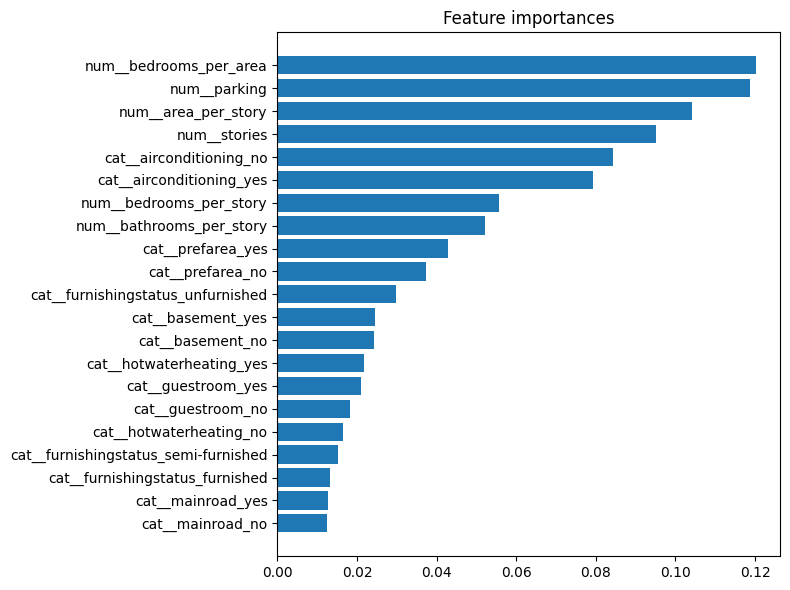

In [31]:
names, importances = zip(*feature_importance_list)
plt.figure(figsize=(8, 6))
plt.barh(y=names, width=importances)
plt.gca().invert_yaxis()
plt.title("Feature importances")
plt.tight_layout()
plt.show()


## Save the Final Pipeline



In [32]:
joblib.dump(final_model, "housing_model.pkl")
print("Model saved successfully.")


Model saved successfully.
